<a href="https://colab.research.google.com/github/Rupashree0806/rupa-codeboosters-2026/blob/main/miniproject5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
API_KEY='93535d167503396f377d6ea46d4f3d8a'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai', 'Delhi','Banglore','Chennai', 'Hydrabad','Kolkata','Pune','Jaipur']
print(f'API configured for{len(CITIES)} cities')

API configured for8 cities


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
import requests
import pandas as pd

weather_data = []

for city in CITIES:
    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code == 200:
        data = response.json()

        weather_data.append({
            'city': city,
            'temperature': data['main']['temp'],
            'humidity': data['main']['humidity'],
            'pressure': data['main']['pressure'],
            'wind_speed': data['wind']['speed']
        })

df = pd.DataFrame(weather_data)

df.head()

,city,temperature,humidity,pressure,wind_speed
0,Mumbai,34.99,55,1008,5.14
1,Delhi,35.05,36,1001,3.09
2,Chennai,34.17,59,1005,5.14
3,Kolkata,33.97,62,1003,2.57
4,Pune,35.78,27,1007,6.05


In [5]:
print(df.isnull().sum())

city           0
temperature    0
humidity       0
pressure       0
wind_speed     0
dtype: int64


In [6]:
df = df.drop_duplicates()

In [7]:
print(df.dtypes)

city            object
temperature    float64
humidity         int64
pressure         int64
wind_speed     float64
dtype: object


In [8]:
df['heat_index'] = (
    df['temperature'] +
    (0.1 * df['humidity'])
)

In [9]:
import sqlite3

conn = sqlite3.connect('weather.db')

In [10]:
df.to_sql(
    'weather',
    conn,
    if_exists='replace',
    index=False
)

6

In [11]:
pd.read_sql_query(
    "SELECT * FROM weather",
    conn
)

,city,temperature,humidity,pressure,wind_speed,heat_index
0,Mumbai,34.99,55,1008,5.14,40.49
1,Delhi,35.05,36,1001,3.09,38.65
2,Chennai,34.17,59,1005,5.14,40.07
3,Kolkata,33.97,62,1003,2.57,40.17
4,Pune,35.78,27,1007,6.05,38.48
5,Jaipur,34.62,29,1005,4.12,37.52


In [12]:
pd.read_sql_query("""
SELECT ROUND(AVG(temperature),2)
AS avg_temperature
FROM weather
""", conn)

,avg_temperature
0,34.76


In [13]:
pd.read_sql_query("""
SELECT city,temperature
FROM weather
ORDER BY temperature DESC
LIMIT 1
""", conn)
pd.read_sql_query("""
SELECT city,humidity
FROM weather
ORDER BY humidity DESC
LIMIT 1
""", conn)


,city,humidity
0,Kolkata,62


In [14]:
pd.read_sql_query("""
SELECT ROUND(AVG(wind_speed),2)
AS avg_wind_speed
FROM weather
""", conn)

,avg_wind_speed
0,4.35


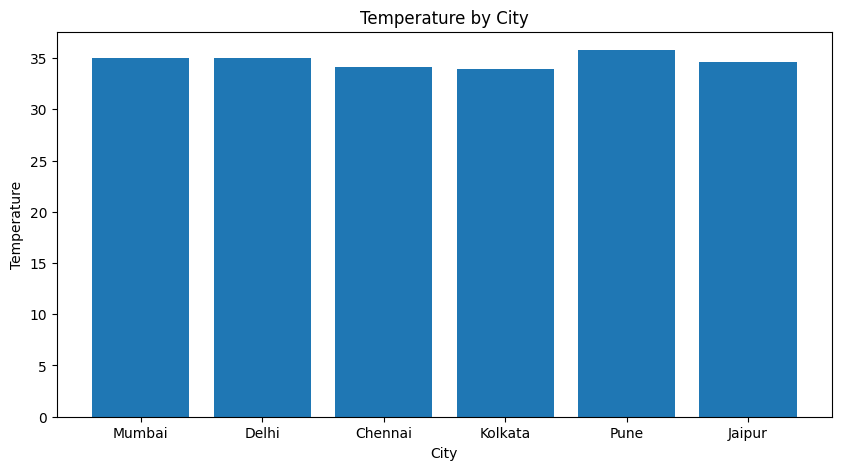

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    df['city'],
    df['temperature']
)

plt.title("Temperature by City")
plt.xlabel("City")
plt.ylabel("Temperature")
plt.show()

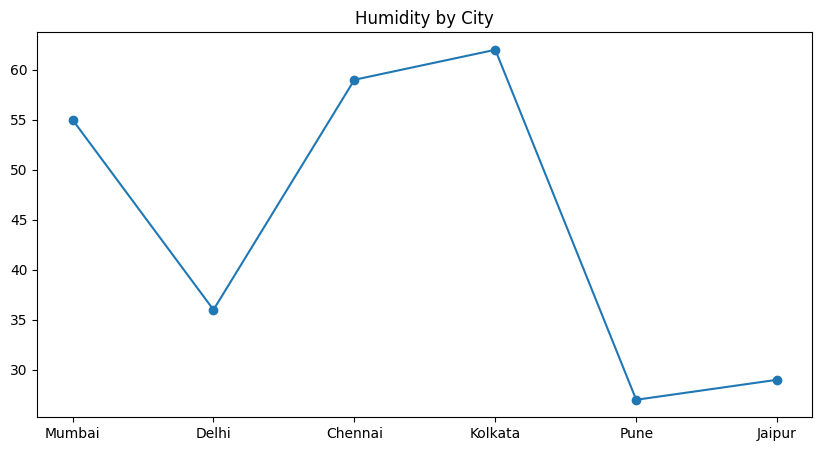

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    df['city'],
    df['humidity'],
    marker='o'
)

plt.title("Humidity by City")
plt.show()

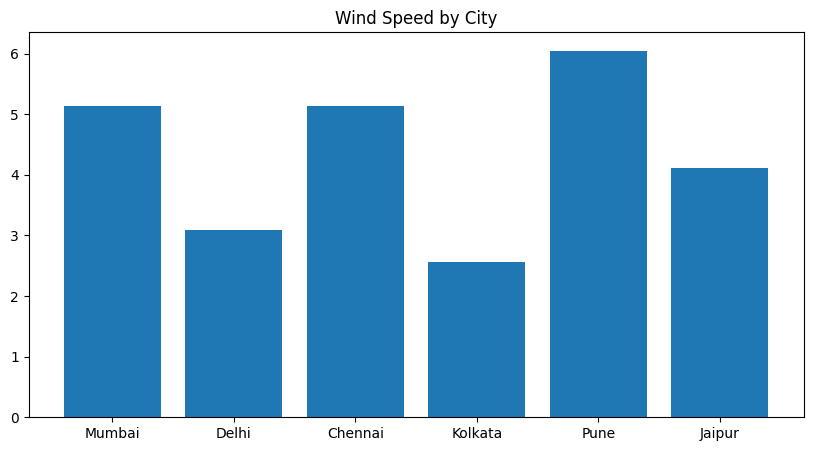

In [17]:

plt.figure(figsize=(10,5))

plt.bar(
    df['city'],
    df['wind_speed']
)

plt.title("Wind Speed by City")
plt.show()

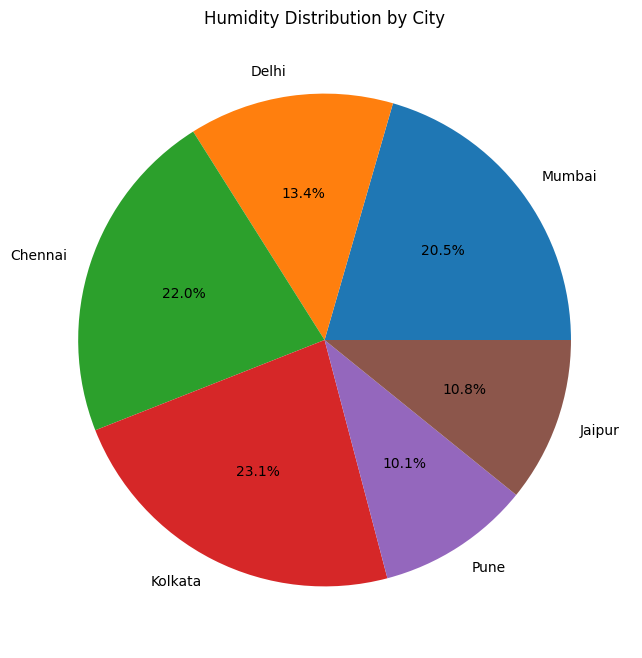

In [26]:
plt.figure(figsize=(8,8))

plt.pie(
    df['humidity'],
    labels=df['city'],
    autopct='%1.1f%%'
)

plt.title('Humidity Distribution by City')

plt.show()

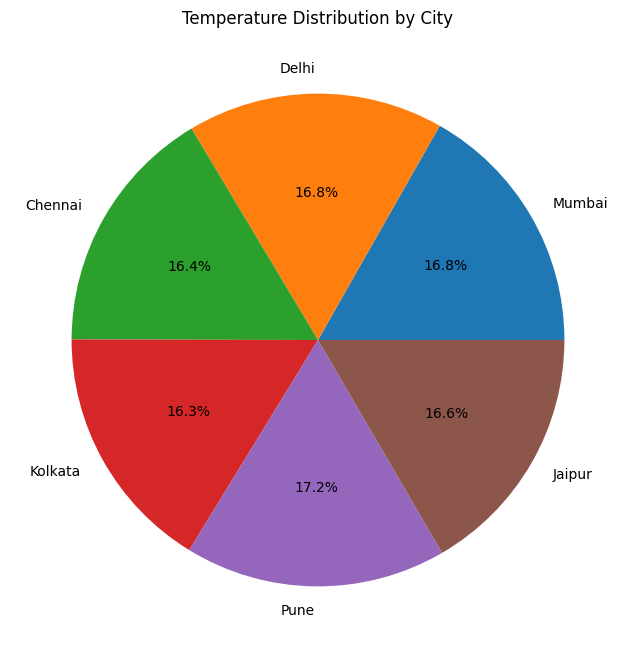

In [27]:
plt.figure(figsize=(8,8))

plt.pie(
    df['temperature'],
    labels=df['city'],
    autopct='%1.1f%%'
)

plt.title('Temperature Distribution by City')

plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [19]:
X = df[['temperature','wind_speed']]
y = df['humidity']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [22]:
predictions = model.predict(X_test)

print(predictions)

[37.85086877 30.67476913]


In [23]:
print(
    "R2 Score:",
    model.score(X_test,y_test)
)

R2 Score: -0.7864309458770116


In [24]:
new_data = [[35,10]]

prediction = model.predict(new_data)

print(
    "Predicted Humidity:",
    prediction[0]
)

Predicted Humidity: 51.309656438688535


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
df.to_csv(
    "weather_final.csv",
    index=False
)